1.Install dependencies

In [1]:
!pip install ultralytics openai pillow matplotlib -q
!pip install python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.6 MB/s eta 0:00:00


2.Imports

In [2]:
from ultralytics import YOLO

from google.colab import files

from PIL import Image

from openai import OpenAI

import matplotlib.pyplot as plt

from collections import Counter

import base64
import io

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


3.Upload YOLO model

In [3]:
uploaded_model = files.upload()

model_filename = list(uploaded_model.keys())[0]

model = YOLO(model_filename)

print("YOLO model loaded")

Saving best (1).pt to best (1).pt
YOLO model loaded


4.Upload image

In [6]:
uploaded_image = files.upload()

image_filename = list(uploaded_image.keys())[0]

print("Image uploaded")

Saving tset.jpg to tset.jpg
Image uploaded


5.Show image

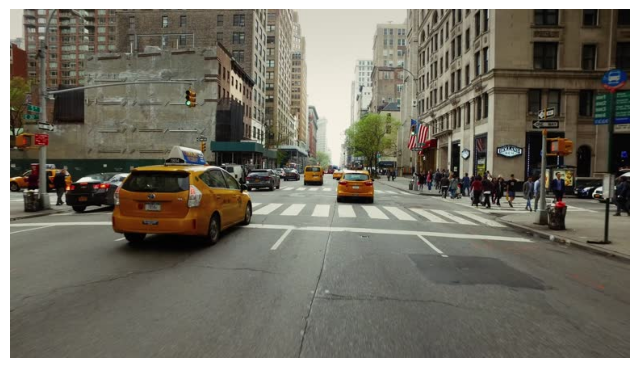

In [7]:
def show_image(image_path):

    img = Image.open(image_path)

    plt.figure(figsize=(8, 6))

    plt.imshow(img)

    plt.axis("off")

    plt.show()

show_image(image_filename)

6.Run YOLO


image 1/1 /content/tset.jpg: 384x640 7 cars, 15 pedestrians, 1 green, 48.2ms
Speed: 11.2ms preprocess, 48.2ms inference, 49.2ms postprocess per image at shape (1, 3, 384, 640)


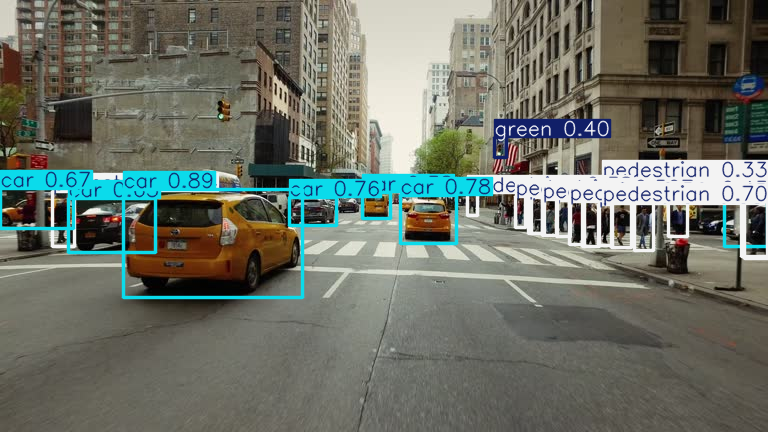

Detection complete


In [8]:
results = model(image_filename)[0]

results.show()

print("Detection complete")

7.Detection summary

In [12]:
def detections_summary(results, conf_threshold=0.1):

    names = results.names

    boxes = results.boxes

    labels = []

    for box in boxes:

        conf = float(box.conf[0])

        if conf < conf_threshold:
            continue

        cls_id = int(box.cls[0])

        labels.append(names[cls_id])

    counts = Counter(labels)

    return "\n".join([f"{k}: {v}" for k, v in counts.items()])

report = detections_summary(results)

print(report)

car: 7
pedestrian: 15
green: 1


7.1.Visualise detections


image 1/1 /content/tset.jpg: 384x640 7 cars, 15 pedestrians, 1 green, 10.9ms
Speed: 2.0ms preprocess, 10.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
=== YOLO DETECTIONS ===
car: 7
pedestrian: 15
green: 1


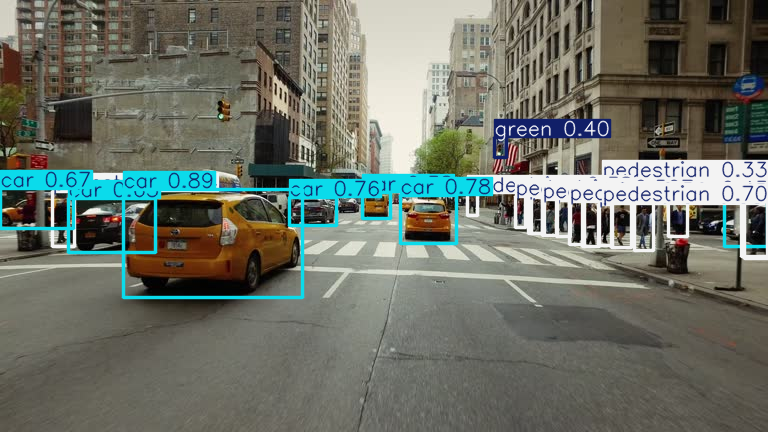

In [13]:
results = model(image_filename)[0]

report = detections_summary(results)

print("=== YOLO DETECTIONS ===")
print(report)

results.show()

8.Groq setup

In [19]:
from dotenv import load_dotenv
from pathlib import Path
from openai import OpenAI
import os

env_path = Path(__file__).resolve().parent.parent / ".env"

load_dotenv(env_path)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env")

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"

print("Groq client ready")

9.Encode image

In [20]:
def encode_image(image_path, max_size=512):

    img = Image.open(image_path)

    img.thumbnail((max_size, max_size))

    if img.mode != "RGB":
        img = img.convert("RGB")

    buffer = io.BytesIO()

    img.save(buffer, format="JPEG", quality=70)

    return base64.b64encode(buffer.getvalue()).decode("utf-8")

10.Scenario 1 (image + detections)

In [21]:
def ask_llava_with_image(image_path, report):

    b64_image = encode_image(image_path)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_image}"
                    }
                },
                {
                    "type": "text",
                    "text": f"""
You are an intelligent driving scene analysis system.

You are given objects detected from a road image by a vision model.
These detections are accurate and should be trusted.

Detected Objects:
{report}

Based on this, provide:

1. Scene Description
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. Risk Assessment
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. Recommended Driving Action
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. Reasoning
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
                }
            ]
        }]
    )

    return response.choices[0].message.content

11.Scenario 2 (detections only)

In [22]:
def ask_llava_with_context(report):

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": f"""
You are an intelligent driving scene analysis system.

You are given objects detected from a road image by a vision model.
These detections are accurate and should be trusted.

Detected Objects:
{report}

Based on this, provide:

1. Scene Description
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. Risk Assessment
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. Recommended Driving Action
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. Reasoning
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
        }]
    )

    return response.choices[0].message.content

12.Run scenario 1

In [23]:
response_image = ask_llava_with_image(image_filename, report)

print(response_image)



## Scene Description

The scene depicts a busy urban street with multiple cars and pedestrians. There are 7 cars detected, with one yellow taxi in the foreground and another in the distance. Fifteen pedestrians are scattered along the sidewalk and potentially crossing or about to cross the road. A green traffic light is visible, indicating that the cars have the right of way.

## Risk Assessment

- **Potential Dangers**: The presence of pedestrians along the sidewalk and potentially crossing or about to cross the road poses a significant risk. The number of pedestrians (15) and their proximity to the road increase the risk of a potential collision.
- **Risk Level**: Medium to High. The risk level is elevated due to the number of pedestrians and their potential movement onto the road.

## Recommended Driving Action

- **Action**: Proceed with caution, be prepared to stop or yield.
- **Specific Action**: Slow down as you approach the crosswalk, be vigilant for pedestrians stepping onto t

13.Run scenario 2

In [24]:
response_text = ask_llava_with_context(report)

print(response_text)

**Scene Description**
The scene shows a busy road with 7 cars and 15 pedestrians present. There is also 1 green traffic light. The presence of a green light indicates that the traffic is currently flowing, but the high number of pedestrians suggests that some may be crossing or preparing to cross the road.

**Risk Assessment**
Potential dangers include collision risk with pedestrians, especially if they are crossing or stepping off the curb. The proximity of pedestrians to the road and the number of cars present increase the risk. However, the green light indicates that traffic movement is expected. The risk level is classified as **medium**, given the moderate traffic and pedestrian activity.

**Recommended Driving Action**
The driver or autonomous system should **proceed with caution**, maintaining a safe speed and being prepared to stop or slow down at any moment, especially when approaching pedestrian crossings or areas with high pedestrian activity.

**Reasoning**
The recommendati

14.Scenario 3 only image no model output

In [25]:
def ask_llava_with_image_no_model(image_path, report):

    b64_image = encode_image(image_path)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_image}"
                    }
                },
                {
                    "type": "text",
                    "text": f"""
You are an intelligent driving scene analysis system.


Based on this, provide:

1. Scene Description
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. Risk Assessment
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. Recommended Driving Action
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. Reasoning
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
                }
            ]
        }]
    )

    return response.choices[0].message.content

15.Run scenario 3

In [27]:
response_image_no_model = ask_llava_with_image_no_model(image_filename, report)

print(response_image_no_model)



## Scene Description

The scene depicts a busy urban street with multiple lanes, featuring several yellow taxis and other vehicles. A taxi is approaching a crosswalk where pedestrians are present. The taxi appears to be yielding to pedestrians. Other taxis and vehicles are seen in the distance, some approaching the intersection. The scene suggests a typical urban driving environment with attention to pedestrian traffic.

## Risk Assessment

- **Potential Dangers:** 
  - A pedestrian might step into the crosswalk as the taxi approaches.
  - Other vehicles might enter the intersection from different directions.
- **Risk Level:** Medium

## Recommended Driving Action

The driver or autonomous system should **proceed with caution** and **yield to pedestrians** in the crosswalk. If there are pedestrians present or about to enter the crosswalk, the vehicle should **come to a stop** and wait until the pedestrians have cleared the crosswalk.

## Reasoning

The recommendation is based on the pr